# Tuning hyperparameters

Set directory

In [1]:
import sys
import os

# Find the project root (Speciale_Kode)
current_dir = os.getcwd()
project_root = current_dir

# Looks for "Speciale_Kode" folder:
while os.path.basename(project_root) != "Speciale_Kode":
    project_root = os.path.dirname(project_root)

# Add to Python path
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
# wandb key: wandb_v1_Q06Vm5akOKLtJXwpM9PMWBzX9UO
from Modules.Load_RF_forecast_models import load_rf_models
rf_models = load_rf_models()

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: Currently logged in as: chrso19 (Energinet_speciale) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Downloading large artifact 'rf_OffshoreWindPower_DK1:latest', 1817.80MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.3 (5284.3MB/s)
c:\Users\chris\anaconda3\envs\ds809\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\chris\anaconda3\envs\ds809\lib\site-p

✓ Loaded RF model for OffshoreWindPower_DK1 from C:\Users\chris\Documents\Python\Personlig\Artifacts\OffshoreWindPower_DK1


wandb: Downloading large artifact 'rf_OffshoreWindPower_DK2:latest', 1809.79MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.4 (5041.2MB/s)


✓ Loaded RF model for OffshoreWindPower_DK2 from C:\Users\chris\Documents\Python\Personlig\Artifacts\OffshoreWindPower_DK2


wandb: Downloading large artifact 'rf_OnshoreWindPower_DK1:latest', 1817.91MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.4 (4477.6MB/s)


...

✓ Loaded RF model for SolarPower_DK2 from C:\Users\chris\Documents\Python\Personlig\Artifacts\SolarPower_DK2


wandb: Downloading large artifact 'rf_TotalProduction_DK1:latest', 1817.61MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.5 (3522.5MB/s)


✓ Loaded RF model for TotalProduction_DK1 from C:\Users\chris\Documents\Python\Personlig\Artifacts\TotalProduction_DK1


wandb: Downloading large artifact 'rf_TotalProduction_DK2:latest', 1817.23MB. 2 files...
wandb:   2 of 2 files downloaded.  
Done. 00:00:00.5 (3883.0MB/s)


✓ Loaded RF model for TotalProduction_DK2 from C:\Users\chris\Documents\Python\Personlig\Artifacts\TotalProduction_DK2

✓ Successfully loaded 8 RF models


Load data:

In [3]:
from Modules.read_data import read_data

(
    DK1_train, 
    DK1_test, 
    DK2_train, 
    DK2_test,
    DK1_train_weather, 
    DK1_test_weather, 
    DK2_train_weather, 
    DK2_test_weather
    ) = read_data("combined_data_cleaned_v5.csv")

Notebook_dir: c:\Users\chris\Documents\Python\Speciale_Kode\Modules
Python_dir: c:\Users\chris\Documents\Python\Speciale_Kode
Data_folder: c:\Users\chris\Documents\Python\Speciale_Kode\Data
Training data shape (DK1): (78900, 38)
Test data shape (DK1): (8760, 38)
Test set fraction (DK1): 9.99%
Training data shape (DK2): (78900, 38)
Test data shape (DK2): (8760, 38)
Test set fraction (DK2): 9.99%


## Import model and choose parameter search grid

In [4]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
# Import model library. E.g.:
# from sklearn.svm import SVR
from sklearn.svm import SVR
from Modules.Load_RF_forecast_models import load_rf_models

# load_rf_models currently supports only the optional timeout argument.
rf_models = load_rf_models()

# Initialize model:
model = SVR()

# Keep at least one number in each list to avoid wrong calculation of total combinations
# If a parameter is not relevant just set a 0 in the list
param_grid = {
    "kernel":  ["rbf"],
    "C":       [0.1, 1, 10, 100],
    "gamma":   ["scale", "auto", 0.01, 0.1],
    "epsilon": [0.01, 0.1, 0.5],
}
num_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"Total number of combinations to test: {num_combinations}")


Total number of combinations to test: 48


## Choose validation setup


**Setup 1**

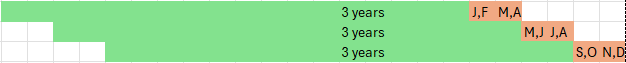

For this setup, val_start in the first fold is fixed at 2024-01-01 00:00:00 and train_end the hour before that (2023-12-31 23:00:00). train_start, val_end and remaining fold values are computed using train_window, predict_horizon and stride.

**Setup 2**



For this setup, val_end in the first fold is fixed at 2024-12-31 23:00:00. train_start, train_end and val_start are computed using train_window and predict_horizon. There is only one fold, so stride has no function.

Write the desired setup number as "split_setup" in the hyper_param_split() function below.

## Find best parameters

### Hyperparameter search for DK1:

Remember to give the right path to save the csv with results!

In [5]:
from skforecast.exceptions import IgnoredArgumentWarning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="Raw feature columns are present")
warnings.filterwarnings("ignore", category=UserWarning, message="Some categorized features not in dataset")
warnings.filterwarnings("ignore", category=UserWarning, message="X does not have valid feature names")
warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

In [6]:
# from Modules.Cross_Validation_runner import run_cross_validation
from Modules.Validation2 import run_cross_validation
import itertools
import pandas as pd
import os

print(f"Total number of combinations to test: {num_combinations}")

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

split_setup = 2

results = []
for comb_number, combination in enumerate(all_combinations, start=1):
    params = dict(zip(param_names, combination))

    print(f"\nCombination {comb_number}/{num_combinations}: {params}")

    model.set_params(**params)
    combination_results = run_cross_validation(
        model = model,
        dataset = DK1_train,
        dk_zone = "DK1",
        split_setup = split_setup,
        train_window = 3 * 8760,        # 8760 hours = 1 year
        predict_horizon = 4 * 168,     # 168 hours = 1 week
        stride = 13 * 168,              
        use_scaler = True,              # Set to True for models that needs feature scaling
        print_fold_results = False,     # Print weekly results for each fold in each combination?
        plot = False,                   # Plot daily SMAPE values for the entire predict_horizon for each combination? 
        rf_models = rf_models,
    )
    row = {
        **params,
        "avg_smape": combination_results["overall_avg_weekly_smape"],
        "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
        "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
        "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
        "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
        "avg_daily_mae": combination_results["overall_avg_daily_mae"],
        "avg_daily_smape": combination_results["overall_avg_daily_smape"],
        "avg_smape_day_1": combination_results["avg_smape_day_1"],
        "avg_smape_day_2": combination_results["avg_smape_day_2"],
        "avg_smape_day_3": combination_results["avg_smape_day_3"],
        "avg_smape_day_4": combination_results["avg_smape_day_4"],
        "avg_smape_day_5": combination_results["avg_smape_day_5"],
        "avg_smape_day_6": combination_results["avg_smape_day_6"],
        "avg_smape_day_7": combination_results["avg_smape_day_7"]
    }
    results.append(row)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "SVR")
base_filename = f"DK1_hyperparameter_results_rbf_split{split_setup}.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"DK1_hyperparameter_results_rbf_split{split_setup}_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))


c:\Users\chris\anaconda3\envs\ds809\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total number of combinations to test: 48

Combination 1/48: {'kernel': 'rbf', 'C': 0.1, 'gamma': 'scale', 'epsilon': 0.01}
Model trained. Now validating on 4 folds...

Average RMSE across all weeks in all folds: 364.681

Average MAE across all weeks in all folds: 303.468

Average SMAPE across all weeks in all folds: 59.385

Combination 2/48: {'kernel': 'rbf', 'C': 0.1, 'gamma': 'scale', 'epsilon': 0.1}
Model trained. Now validating on 4 folds...

Average RMSE across all weeks in all folds: 364.697

Average MAE across all weeks in all folds: 303.485

Average SMAPE across all weeks in all folds: 59.387

Combination 3/48: {'kernel': 'rbf', 'C': 0.1, 'gamma': 'scale', 'epsilon': 0.5}
Model trained. Now validating on 4 folds...

Average RMSE across all weeks in all folds: 364.658

Average MAE across all weeks in all folds: 303.444

Average SMAPE across all weeks in all folds: 59.383

Combination 4/48: {'kernel': 'rbf', 'C': 0.1, 'gamma': 'auto', 'epsilon': 0.01}
Model trained. Now validatin

KeyboardInterrupt: 

### Hyperparameter search for DK2:

Remember to give the right path to save the csv with resutls!

In [ ]:
# from Modules.Cross_Validation_runner import run_cross_validation
from Modules.Validation2 import run_cross_validation
import itertools
import pandas as pd
import os

print(f"Total number of combinations to test: {num_combinations}")

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

split_setup = 2

results = []
for comb_number, combination in enumerate(all_combinations, start=1):
    params = dict(zip(param_names, combination))

    print(f"\nCombination {comb_number}/{num_combinations}: {params}")

    model.set_params(**params)
    combination_results = run_cross_validation(
        model = model,
        dataset = DK2_train,
        dk_zone = "DK2",
        split_setup = split_setup,
        train_window = 3 * 8760,        # 8760 hours = 1 year
        predict_horizon = 4 * 168,     # 168 hours = 1 week
        stride = 13 * 168,            
        use_scaler = True,              # Set to True for models that needs feature scaling
        print_fold_results = False,     # Print weekly results for each fold in each combination?
        plot = False,                   # Plot daily SMAPE values for the entire predict_horizon for each combination? 
        rf_models = rf_models,
    )
    row = {
        **params,
        "avg_smape": combination_results["overall_avg_weekly_smape"],
        "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
        "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
        "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
        "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
        "avg_daily_mae": combination_results["overall_avg_daily_mae"],
        "avg_daily_smape": combination_results["overall_avg_daily_smape"],
        "avg_smape_day_1": combination_results["avg_smape_day_1"],
        "avg_smape_day_2": combination_results["avg_smape_day_2"],
        "avg_smape_day_3": combination_results["avg_smape_day_3"],
        "avg_smape_day_4": combination_results["avg_smape_day_4"],
        "avg_smape_day_5": combination_results["avg_smape_day_5"],
        "avg_smape_day_6": combination_results["avg_smape_day_6"],
        "avg_smape_day_7": combination_results["avg_smape_day_7"]
    }
    results.append(row)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "SVR")
base_filename = f"DK2_hyperparameter_results_rbf_split{split_setup}.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"DK2_hyperparameter_results_rbf_split{split_setup}_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))


In [7]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
# Import model library. E.g.:
# from sklearn.svm import SVR
from sklearn.svm import SVR
from Modules.Load_RF_forecast_models import load_rf_models

# load_rf_models currently supports only the optional timeout argument.
rf_models = load_rf_models()

# Initialize model:
model = SVR()

# Keep at least one number in each list to avoid wrong calculation of total combinations
# If a parameter is not relevant just set a 0 in the list
param_grid = {
    "kernel":  ["linear"],
    "C":       [0.1, 1, 10, 100],
    "gamma":   ["scale"],   # placeholder — has no effect on linear kernel
    "epsilon": [0.01, 0.1, 0.5],
}
num_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"Total number of combinations to test: {num_combinations}")


Total number of combinations to test: 12


In [ ]:
# from Modules.Cross_Validation_runner import run_cross_validation
from Modules.Validation2 import run_cross_validation
import itertools
import pandas as pd
import os

print(f"Total number of combinations to test: {num_combinations}")

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

split_setup = 2

results = []
for comb_number, combination in enumerate(all_combinations, start=1):
    params = dict(zip(param_names, combination))

    print(f"\nCombination {comb_number}/{num_combinations}: {params}")

    model.set_params(**params)
    combination_results = run_cross_validation(
        model = model,
        dataset = DK1_train,
        dk_zone = "DK1",
        split_setup = split_setup,
        train_window = 3 * 8760,        # 8760 hours = 1 year
        predict_horizon = 4 * 168,     # 168 hours = 1 week
        stride = 13 * 168,            
        use_scaler = True,              # Set to True for models that needs feature scaling
        print_fold_results = False,     # Print weekly results for each fold in each combination?
        plot = False,                   # Plot daily SMAPE values for the entire predict_horizon for each combination? 
        rf_models = rf_models,
    )
    row = {
        **params,
        "avg_smape": combination_results["overall_avg_weekly_smape"],
        "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
        "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
        "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
        "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
        "avg_daily_mae": combination_results["overall_avg_daily_mae"],
        "avg_daily_smape": combination_results["overall_avg_daily_smape"],
        "avg_smape_day_1": combination_results["avg_smape_day_1"],
        "avg_smape_day_2": combination_results["avg_smape_day_2"],
        "avg_smape_day_3": combination_results["avg_smape_day_3"],
        "avg_smape_day_4": combination_results["avg_smape_day_4"],
        "avg_smape_day_5": combination_results["avg_smape_day_5"],
        "avg_smape_day_6": combination_results["avg_smape_day_6"],
        "avg_smape_day_7": combination_results["avg_smape_day_7"]
    }
    results.append(row)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "SVR")
base_filename = f"DK1_hyperparameter_results_linear_split{split_setup}.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"DK1_hyperparameter_results_linear_split{split_setup}_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))


In [ ]:
# from Modules.Cross_Validation_runner import run_cross_validation
from Modules.Validation2 import run_cross_validation
import itertools
import pandas as pd
import os

print(f"Total number of combinations to test: {num_combinations}")

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

split_setup = 2

results = []
for comb_number, combination in enumerate(all_combinations, start=1):
    params = dict(zip(param_names, combination))

    print(f"\nCombination {comb_number}/{num_combinations}: {params}")

    model.set_params(**params)
    combination_results = run_cross_validation(
        model = model,
        dataset = DK2_train,
        dk_zone = "DK2",
        split_setup = split_setup,
        train_window = 3 * 8760,        # 8760 hours = 1 year
        predict_horizon = 4 * 168,     # 168 hours = 1 week
        stride = 13 * 168,          
        use_scaler = True,              # Set to True for models that needs feature scaling
        print_fold_results = False,     # Print weekly results for each fold in each combination?
        plot = False,                   # Plot daily SMAPE values for the entire predict_horizon for each combination? 
        rf_models = rf_models,
    )
    row = {
        **params,
        "avg_smape": combination_results["overall_avg_weekly_smape"],
        "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
        "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
        "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
        "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
        "avg_daily_mae": combination_results["overall_avg_daily_mae"],
        "avg_daily_smape": combination_results["overall_avg_daily_smape"],
        "avg_smape_day_1": combination_results["avg_smape_day_1"],
        "avg_smape_day_2": combination_results["avg_smape_day_2"],
        "avg_smape_day_3": combination_results["avg_smape_day_3"],
        "avg_smape_day_4": combination_results["avg_smape_day_4"],
        "avg_smape_day_5": combination_results["avg_smape_day_5"],
        "avg_smape_day_6": combination_results["avg_smape_day_6"],
        "avg_smape_day_7": combination_results["avg_smape_day_7"]
    }
    results.append(row)
# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "SVR")
base_filename = f"DK2_hyperparameter_results_linear_split{split_setup}.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"DK2_hyperparameter_results_linear_split{split_setup}_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))


Total number of combinations to test: 12

Combination 1/12: {'kernel': 'linear', 'C': 0.1, 'gamma': 'scale', 'epsilon': 0.01}
Model trained. Now validating on 4 folds...

Average RMSE across all weeks in all folds: 337.840

Average MAE across all weeks in all folds: 257.855

Average SMAPE across all weeks in all folds: 66.019

Combination 2/12: {'kernel': 'linear', 'C': 0.1, 'gamma': 'scale', 'epsilon': 0.1}
Model trained. Now validating on 4 folds...

Average RMSE across all weeks in all folds: 337.861

Average MAE across all weeks in all folds: 257.872

Average SMAPE across all weeks in all folds: 66.027

Combination 3/12: {'kernel': 'linear', 'C': 0.1, 'gamma': 'scale', 'epsilon': 0.5}
Model trained. Now validating on 4 folds...

Average RMSE across all weeks in all folds: 337.891

Average MAE across all weeks in all folds: 257.888

Average SMAPE across all weeks in all folds: 66.009

Combination 4/12: {'kernel': 'linear', 'C': 1, 'gamma': 'scale', 'epsilon': 0.01}
Model trained. No

: 

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
# Import model library. E.g.:
# from sklearn.svm import SVR
from sklearn.svm import SVR
from Modules.Load_RF_forecast_models import load_rf_models

# load_rf_models currently supports only the optional timeout argument.
rf_models = load_rf_models()

# Initialize model:
model = SVR()

# Keep at least one number in each list to avoid wrong calculation of total combinations
# If a parameter is not relevant just set a 0 in the list
param_grid = {
    "kernel":  ["poly"],
    "C":       [0.1, 1, 10, 100],
    "gamma":   ["scale", "auto"],   # no numeric gamma values
    "epsilon": [0.01, 0.1, 0.5],
    "degree":  [2],                 # degree=3 (default) risks overflow
}
num_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"Total number of combinations to test: {num_combinations}")


In [ ]:
# from Modules.Cross_Validation_runner import run_cross_validation
from Modules.Validation2 import run_cross_validation
import itertools
import pandas as pd
import os

print(f"Total number of combinations to test: {num_combinations}")

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

split_setup = 2

results = []
for comb_number, combination in enumerate(all_combinations, start=1):
    params = dict(zip(param_names, combination))

    print(f"\nCombination {comb_number}/{num_combinations}: {params}")

    model.set_params(**params)
    combination_results = run_cross_validation(
        model = model,
        dataset = DK1_train,
        dk_zone = "DK1",
        split_setup = split_setup,
        train_window = 3 * 8760,        # 8760 hours = 1 year
        predict_horizon = 4 * 168,     # 168 hours = 1 week
        stride = 13 * 168,            
        use_scaler = True,              # Set to True for models that needs feature scaling
        print_fold_results = False,     # Print weekly results for each fold in each combination?
        plot = False,                   # Plot daily SMAPE values for the entire predict_horizon for each combination? 
        rf_models = rf_models,
    )
    row = {
        **params,
        "avg_smape": combination_results["overall_avg_weekly_smape"],
        "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
        "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
        "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
        "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
        "avg_daily_mae": combination_results["overall_avg_daily_mae"],
        "avg_daily_smape": combination_results["overall_avg_daily_smape"],
        "avg_smape_day_1": combination_results["avg_smape_day_1"],
        "avg_smape_day_2": combination_results["avg_smape_day_2"],
        "avg_smape_day_3": combination_results["avg_smape_day_3"],
        "avg_smape_day_4": combination_results["avg_smape_day_4"],
        "avg_smape_day_5": combination_results["avg_smape_day_5"],
        "avg_smape_day_6": combination_results["avg_smape_day_6"],
        "avg_smape_day_7": combination_results["avg_smape_day_7"]
    }
    results.append(row)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "SVR")
base_filename = f"DK1_hyperparameter_results_poly_split{split_setup}.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"DK1_hyperparameter_results_poly_split{split_setup}_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))


In [ ]:
# from Modules.Cross_Validation_runner import run_cross_validation
from Modules.Validation2 import run_cross_validation
import itertools
import pandas as pd
import os

print(f"Total number of combinations to test: {num_combinations}")

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

split_setup = 2

results = []
for comb_number, combination in enumerate(all_combinations, start=1):
    params = dict(zip(param_names, combination))

    print(f"\nCombination {comb_number}/{num_combinations}: {params}")

    model.set_params(**params)
    combination_results = run_cross_validation(
        model = model,
        dataset = DK2_train,
        dk_zone = "DK2",
        split_setup = split_setup,
        train_window = 3 * 8760,        # 8760 hours = 1 year
        predict_horizon = 4 * 168,     # 168 hours = 1 week
        stride = 13 * 168,           
        use_scaler = True,              # Set to True for models that needs feature scaling
        print_fold_results = False,     # Print weekly results for each fold in each combination?
        plot = False,                   # Plot daily SMAPE values for the entire predict_horizon for each combination? 
        rf_models = rf_models,
    )
    row = {
        **params,
        "avg_smape": combination_results["overall_avg_weekly_smape"],
        "avg_weekly_rmse": combination_results["overall_avg_weekly_rmse"],
        "avg_weekly_mae": combination_results["overall_avg_weekly_mae"],
        "avg_weekly_smape": combination_results["overall_avg_weekly_smape"],
        "avg_daily_rmse": combination_results["overall_avg_daily_rmse"],
        "avg_daily_mae": combination_results["overall_avg_daily_mae"],
        "avg_daily_smape": combination_results["overall_avg_daily_smape"],
        "avg_smape_day_1": combination_results["avg_smape_day_1"],
        "avg_smape_day_2": combination_results["avg_smape_day_2"],
        "avg_smape_day_3": combination_results["avg_smape_day_3"],
        "avg_smape_day_4": combination_results["avg_smape_day_4"],
        "avg_smape_day_5": combination_results["avg_smape_day_5"],
        "avg_smape_day_6": combination_results["avg_smape_day_6"],
        "avg_smape_day_7": combination_results["avg_smape_day_7"]
    }
    results.append(row)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = os.path.join(project_root, "Shallow learners")
folder = os.path.join(folder, "SVR")
base_filename = f"DK2_hyperparameter_results_poly_split{split_setup}.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"DK2_hyperparameter_results_poly_split{split_setup}_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False, decimal=",")

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))
